# Weather Data Analysis

## Introduction :

Weather data plays an important role in understanding environmental patterns and climate behavior.
In this notebook, we perform Exploratory Data Analysis (EDA) on a weather dataset to identify patterns in temperature and precipitation.

The goal of this analysis is to explore the dataset, clean the data, visualize relationships between variables, and derive meaningful insights from weather trends.

## Objectives :

• Understand the dataset structure  
• Perform data cleaning  
• Analyze temperature distributions  
• Explore relationships between weather variables  
• Identify correlations and trends in weather patterns

## Importing Required Libraries :

To perform data analysis and visualization, we import the following Python libraries:

- **Pandas** for data manipulation
- **NumPy** for numerical operations
- **Matplotlib** for basic plotting
- **Seaborn** for advanced statistical visualization

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")

## Loading the Dataset :

The dataset is loaded using the Pandas library.
Once loaded, we preview the first few rows to understand the structure of the data and the available variables.

In [2]:
df = pd.read_csv("climate.csv")

df.head()

,DATE,PRCP,SNOW,SNWD,TMAX,TMIN
0,10/26/2016,0.00,0.0,0.0,62,34
1,10/27/2016,0.00,0.0,0.0,66,37
2,10/28/2016,0.00,0.0,0.0,62,40
3,10/29/2016,0.02,0.0,0.0,61,41
4,10/30/2016,0.00,0.0,0.0,62,40


##Insight :

The dataset preview helps confirm that the file has been loaded correctly.
It also provides an initial understanding of the variables available for analysis such as temperature and precipitation.

## Dataset Overview :

Before starting the analysis, it is important to understand the dataset's structure.

We examine:
- Number of rows and columns
- Data types
- Summary statistics

In [3]:
df.shape

(1062, 6)

##Insight :
The dataset size helps us understand how many observations and features are available for analysis.

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1062 entries, 0 to 1061
Data columns (total 6 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   DATE    1062 non-null   object 
 1   PRCP    1062 non-null   float64
 2   SNOW    1061 non-null   float64
 3   SNWD    1061 non-null   float64
 4   TMAX    1062 non-null   int64  
 5   TMIN    1062 non-null   int64  
dtypes: float64(3), int64(2), object(1)
memory usage: 49.9+ KB


##Insight :
The info() function shows the data types of each column and identifies any missing values that may need to be handled during data cleaning.

In [5]:
df.describe()

,PRCP,SNOW,SNWD,TMAX,TMIN
count,1062.000000,1061.000000,1061.000000,1062.000000,1062.000000
mean,0.025471,0.172856,1.467484,56.451977,29.237288
std,0.078693,0.749917,3.292950,21.828676,16.964069
min,0.000000,0.000000,0.000000,-5.000000,-35.000000
25%,0.000000,0.000000,0.000000,38.000000,18.000000
50%,0.000000,0.000000,0.000000,57.000000,30.000000
75%,0.000000,0.000000,0.000000,77.000000,43.000000
max,1.110000,10.000000,16.000000,94.000000,64.000000


##Insight :
The statistical summary provides measures such as mean, minimum, maximum, and standard deviation, which help understand the distribution of numerical variables.

## Data Cleaning :

Real-world datasets often contain missing or inconsistent data.
Cleaning the data ensures the dataset is reliable and suitable for analysis.

Steps performed:
• Check missing values  
• Remove or handle missing entries

In [6]:
df.isnull().sum()

,0
DATE,0
PRCP,0
SNOW,1
SNWD,1
TMAX,0
TMIN,0


##Insight :
This step helps identify whether any columns contain missing values that might affect the analysis.

In [8]:
df = df.dropna()

##Insight :
Rows with missing values are removed to maintain data consistency and ensure accurate analysis.

## Distribution of Maximum Temperature :

Understanding how maximum temperatures are distributed helps identify common weather conditions.
A histogram is used to visualize this distribution.

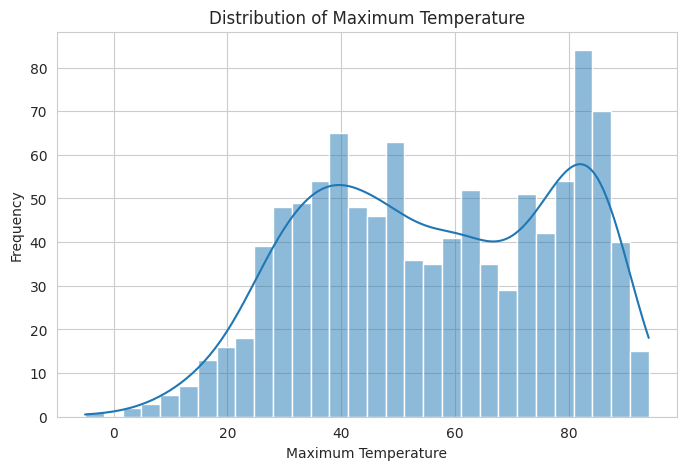

In [9]:
plt.figure(figsize=(8,5))

sns.histplot(df["TMAX"], bins=30, kde=True)

plt.title("Distribution of Maximum Temperature")
plt.xlabel("Maximum Temperature")
plt.ylabel("Frequency")

plt.show()

##Insight :

The histogram reveals how temperature values are spread across the dataset.
Most values cluster within a moderate range, indicating stable temperature conditions.

## Temperature Relationship Analysis :

A scatter plot is used to analyze the relationship between minimum and maximum temperatures.

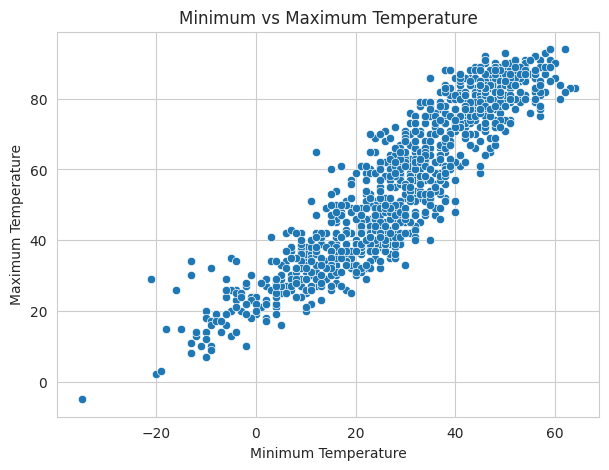

In [10]:
plt.figure(figsize=(7,5))

sns.scatterplot(x=df["TMIN"], y=df["TMAX"])

plt.title("Minimum vs Maximum Temperature")
plt.xlabel("Minimum Temperature")
plt.ylabel("Maximum Temperature")

plt.show()

##Insight :

The scatter plot indicates a strong positive relationship between minimum and maximum temperatures.
This means that when the minimum temperature increases, the maximum temperature also tends to increase.

## Precipitation Distribution :

Precipitation values are analyzed using a box plot to understand the spread and identify outliers.

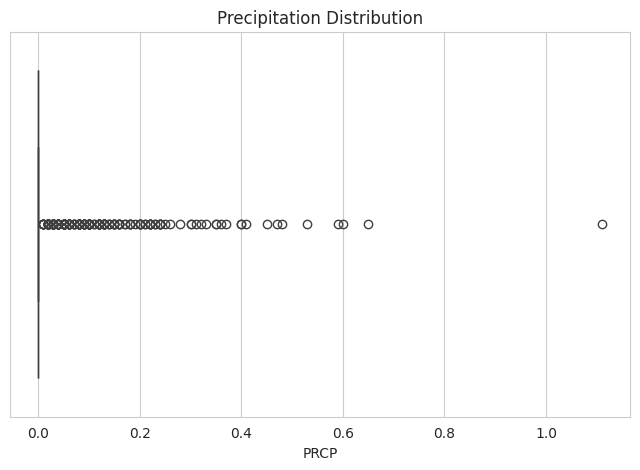

In [11]:
plt.figure(figsize=(8,5))

sns.boxplot(x=df["PRCP"])

plt.title("Precipitation Distribution")

plt.show()

##Insight :

The box plot highlights the distribution of rainfall values.
Outliers represent days with unusually high precipitation compared to normal weather patterns.

## Correlation Analysis :

Correlation analysis helps determine how strongly different variables are related.
A heatmap provides a visual representation of correlation coefficients.

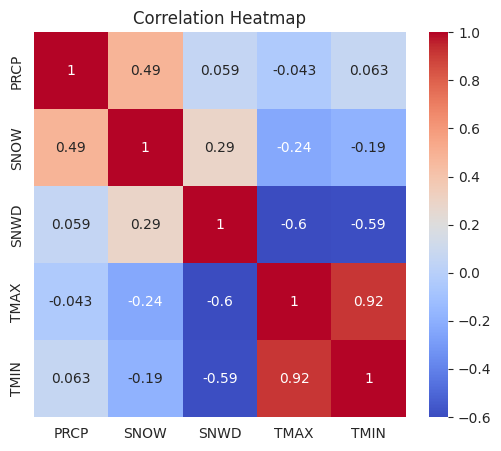

In [15]:
plt.figure(figsize=(6,5))

sns.heatmap(df.select_dtypes(include='number').corr(),
            annot=True,
            cmap="coolwarm")

plt.title("Correlation Heatmap")

plt.show()

##Insight :

Since correlation analysis requires numerical variables, non-numeric columns such as dates are excluded from the calculation.
This ensures that the correlation matrix accurately represents relationships between numerical weather variables.




The heatmap shows strong correlation between minimum and maximum temperatures, indicating that both variables follow similar patterns.

## Pairplot Analysis :

A pairplot helps visualize relationships between multiple variables simultaneously.
It shows scatter plots between variables and distribution plots on the diagonal.

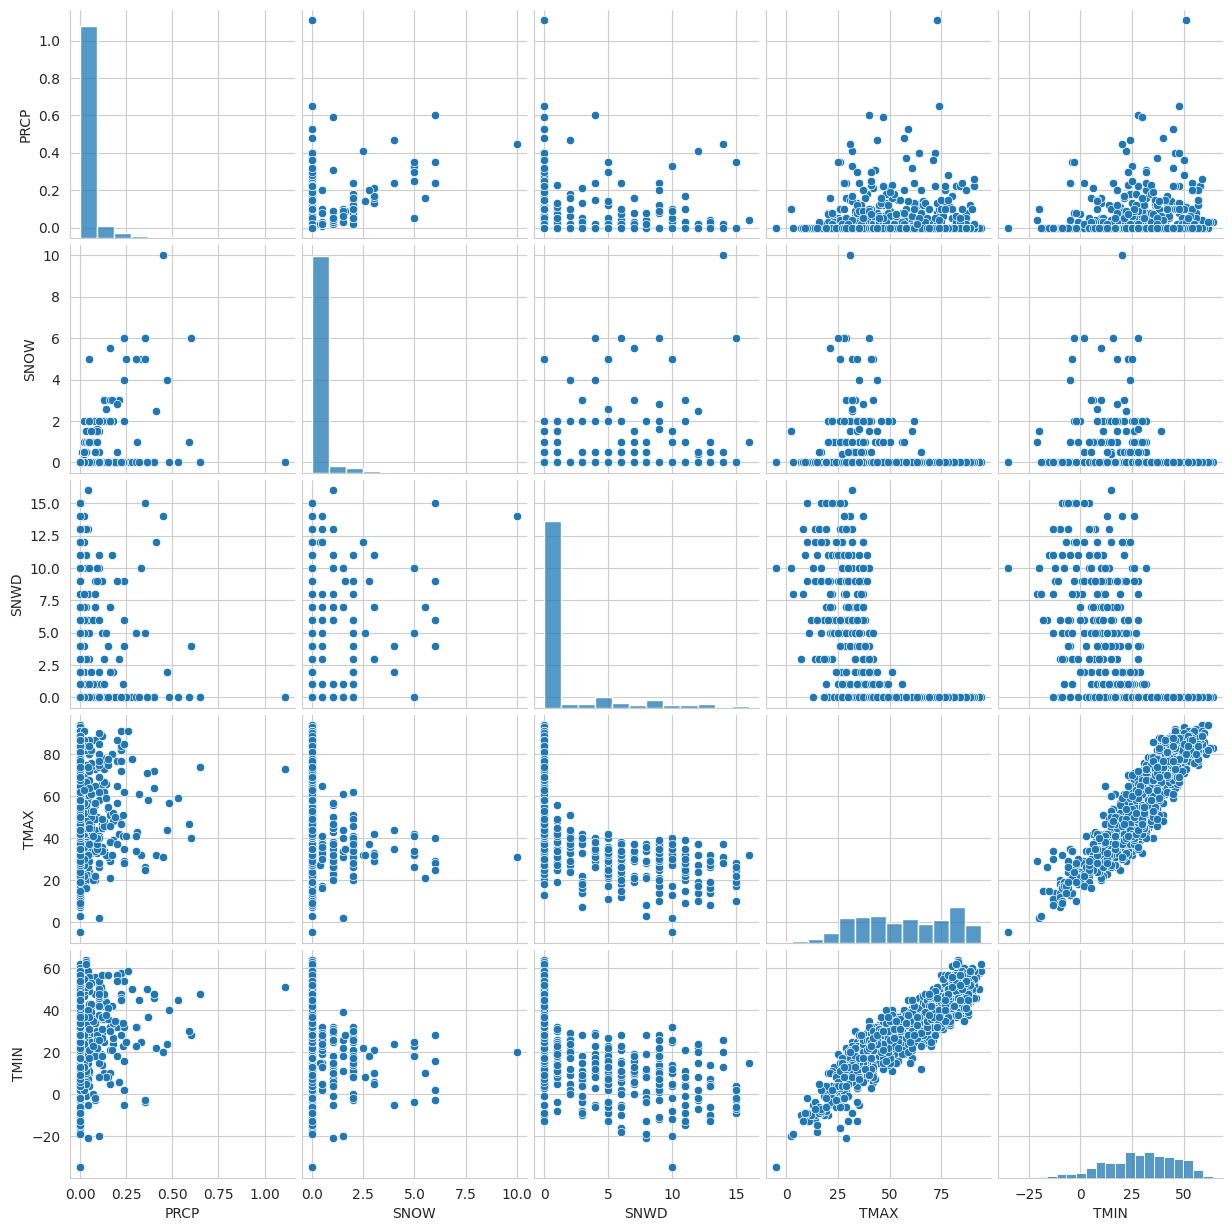

In [16]:
sns.pairplot(df)

plt.show()

##Insight :

The pairplot provides a comprehensive view of relationships between all numerical variables in the dataset.
It helps identify correlations, clusters, and potential patterns across multiple features.

## Temperature Trend Over Observations :

Line plots help visualize how temperature changes across the dataset observations.

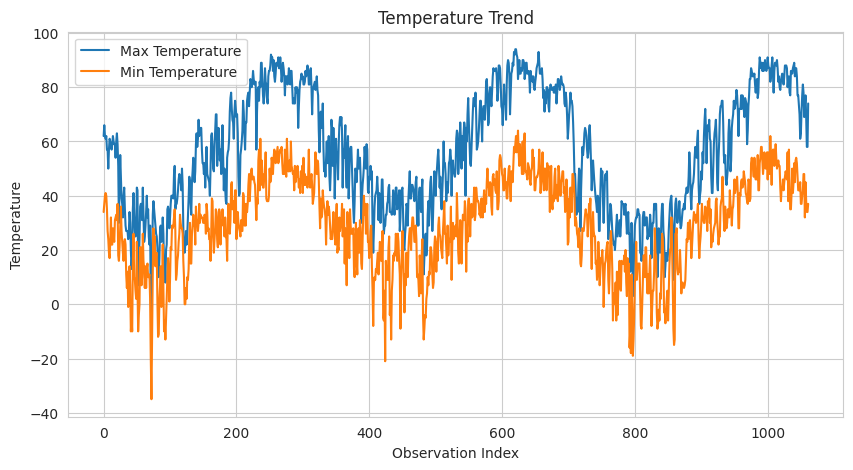

In [17]:
plt.figure(figsize=(10,5))

plt.plot(df["TMAX"], label="Max Temperature")
plt.plot(df["TMIN"], label="Min Temperature")

plt.title("Temperature Trend")
plt.xlabel("Observation Index")
plt.ylabel("Temperature")

plt.legend()

plt.show()

##Insight :

The line chart shows how minimum and maximum temperatures vary across observations.
The two variables follow similar patterns, reinforcing the strong relationship observed earlier.

## Key Insights :

1. Maximum and minimum temperatures show a strong positive correlation.
2. Temperature values are concentrated within a moderate range.
3. Precipitation values show several outliers indicating heavy rainfall events.
4. Visualization techniques help uncover patterns and relationships in weather data.

## Conclusion :

In this notebook, we performed exploratory data analysis on a weather dataset to understand temperature and precipitation patterns.

The analysis revealed strong relationships between temperature variables and provided insights into rainfall distribution.

Future improvements could include:
- Time-series weather forecasting
- Seasonal trend analysis
- Machine learning models for climate prediction